# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [3]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ----------------- ---------------------- 3.9/8.9 MB 21.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.6/8.9 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 17.8 MB/s  0:00:00
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ------- -------------------------------- 7.3/41.3 MB 37.6 MB/s eta 0:00:01
   -------------- ------------------------- 14.9/41.3 MB 37.5 MB/s eta 0:00:01
   ---------------------- ----------------- 23.1/41.3 MB 37.4 MB/s eta 0:00:01
   --------------------------- ------------ 28.8/41.3 MB 34.5 MB/s eta 0:00:01
   -------------------------------- ------- 33.8/41.3 MB 33.0 MB/s eta 0:00:01
   ------------------------------------- -- 38.8/41.3 MB 31.6 MB/s eta 0:00:01
   ---------------------------------------  41.2/41.3 MB 31.1 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 26.2 MB/s  0:00:01

   -

In [4]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = 'data/raw'
processed_dir = 'data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at data/raw\outliers_homework.csv. Skipping CSV creation to avoid overwrite.


In [5]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [6]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [7]:
def detect_outliers_iqr(
    series: pd.Series,
    k: float = 1.5
) -> pd.Series:
    """
    Detect outliers using the Interquartile Range (IQR) method.

    Parameters
    ----------
    series : pd.Series
        Numeric data to evaluate.
    k : float, default=1.5
        Multiplier used to determine the lower and upper
        outlier boundaries.

    Returns
    -------
    pd.Series
        Boolean Series where True indicates an outlier.

    Notes
    -----
    NaN values are not classified as outliers.
    The method assumes quartiles provide a meaningful
    summary of the distribution.
    """

    if series.empty:
        raise ValueError("Input series cannot be empty.")

    if k <= 0:
        raise ValueError("k must be greater than 0.")

    clean_series = series.dropna()

    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return (
        (series < lower)
        | (series > upper)
    ).fillna(False)

def detect_outliers_zscore(
    series: pd.Series,
    threshold: float = 3.0
) -> pd.Series:
    """
    Detect outliers using absolute Z-scores.

    Parameters
    ----------
    series : pd.Series
        Numeric data to evaluate.
    threshold : float, default=3.0
        Observations with absolute Z-score greater than
        this threshold are classified as outliers.

    Returns
    -------
    pd.Series
        Boolean Series where True indicates an outlier.

    Notes
    -----
    Population standard deviation (ddof=0) is used.
    NaN values are not classified as outliers.
    The method works best when the distribution is
    approximately normal.
    """

    if series.empty:
        raise ValueError(
            "Input series cannot be empty."
        )

    if threshold <= 0:
        raise ValueError(
            "threshold must be greater than 0."
        )

    clean_series = series.dropna()

    mu = clean_series.mean()

    sigma = clean_series.std(
        ddof=0
    )

    if sigma == 0:
        return pd.Series(
            False,
            index=series.index
        )

    z = (
        series - mu
    ) / sigma

    return (
        z.abs() > threshold
    ).fillna(False)

*(Stretch)* A working `winsorize_series` is provided below. Improve it if you can - it does not check that `lower` is below `upper` - then use it in the comparison further down.

In [8]:
def winsorize_series(
    series: pd.Series,
    lower: float = 0.05,
    upper: float = 0.95
) -> pd.Series:
    """
    Winsorize a numeric Series by clipping extreme values.

    Parameters
    ----------
    series : pd.Series
        Numeric data to winsorize.
    lower : float, default=0.05
        Lower quantile cutoff.
    upper : float, default=0.95
        Upper quantile cutoff.

    Returns
    -------
    pd.Series
        Winsorized Series.
    """

    if series.empty:
        raise ValueError(
            "Input series cannot be empty."
        )

    if not 0 <= lower < upper <= 1:
        raise ValueError(
            "Require 0 <= lower < upper <= 1."
        )

    lo = series.quantile(lower)
    hi = series.quantile(upper)

    return series.clip(
        lower=lo,
        upper=hi
    )

## Apply Detection and Create Flags (choose a numeric column)

In [9]:
target_col = 'daily_return'
df[target_col].describe()

count    115.000000
mean      -0.001434
std        0.040579
min       -0.196672
25%       -0.008525
50%       -0.000187
75%        0.006368
max        0.212402
Name: daily_return, dtype: float64

In [10]:
df['outlier_iqr'] = detect_outliers_iqr(
    df[target_col],
    k=1.5
)

df['outlier_z'] = detect_outliers_zscore(
    df[target_col],
    threshold=3.0
)

df.head()

,date,daily_return,daily_return_2,outlier_iqr,outlier_z
0,2022-01-03,0.001263,0.003834,False,False
1,2022-01-04,-0.020046,-0.009506,False,False
2,2022-01-05,0.004739,-0.000535,False,False
3,2022-01-06,0.009953,0.012539,False,False
4,2022-01-07,0.008872,0.009840,False,False


In [11]:
print(
    "IQR outliers:",
    df['outlier_iqr'].sum()
)

print(
    "Z-score outliers:",
    df['outlier_z'].sum()
)

IQR outliers: 9
Z-score outliers: 5


In [12]:
df.loc[
    df['outlier_iqr'],
    ['date', 'daily_return']
]

,date,daily_return
41,2022-03-01,0.031952
63,2022-03-31,-0.031101
85,2022-05-02,0.174843
86,2022-05-03,-0.168258
87,2022-05-04,-0.033999
89,2022-05-06,-0.196672
90,2022-05-09,0.212402
92,2022-05-11,0.028711
93,2022-05-12,-0.178729


### Visual Checks (boxplot / histogram)

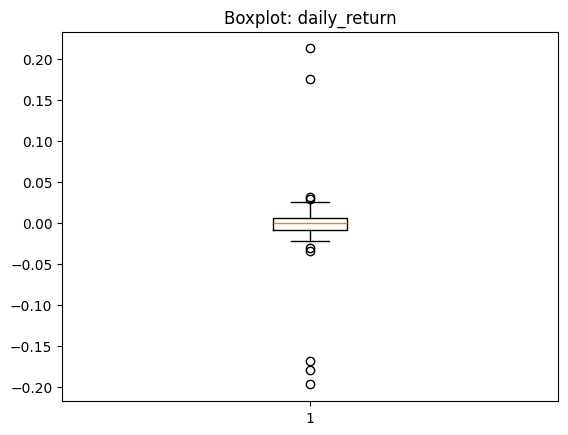

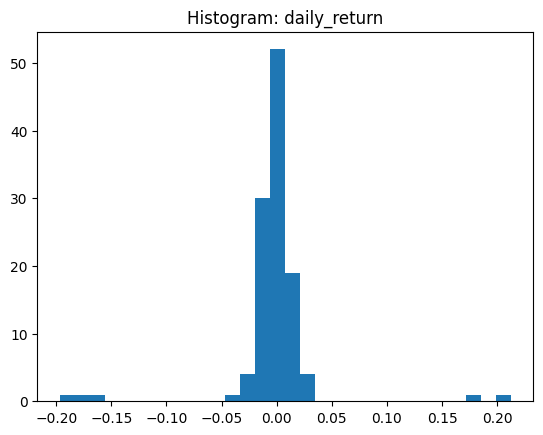

In [14]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

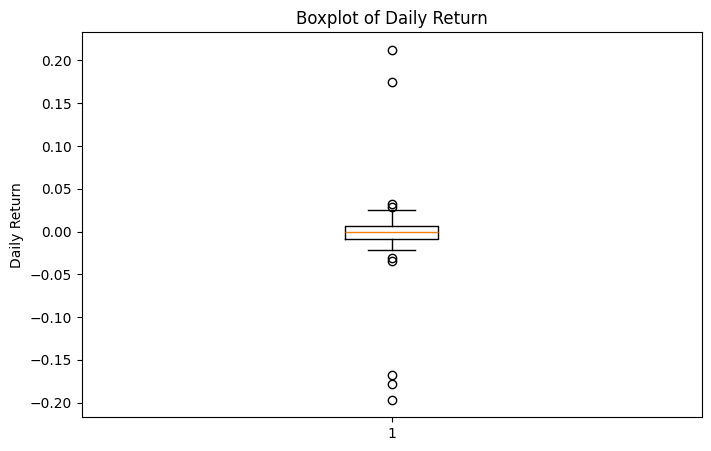

In [13]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    df[target_col].dropna()
)

plt.title(
    'Boxplot of Daily Return'
)

plt.ylabel(
    'Daily Return'
)

plt.show()

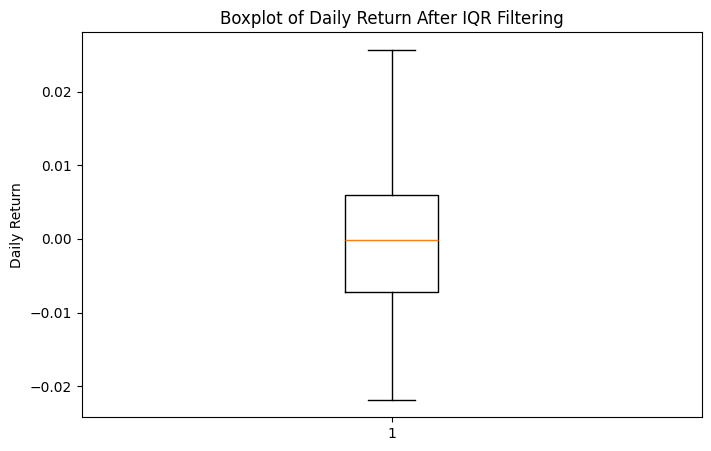

In [15]:
filtered_data = df.loc[
    ~df['outlier_iqr'],
    target_col
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    filtered_data.dropna()
)

plt.title(
    'Boxplot of Daily Return After IQR Filtering'
)

plt.ylabel(
    'Daily Return'
)

plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [16]:
summ_all = (
    df[target_col]
    .describe()[['mean', '50%', 'std']]
    .rename({
        '50%': 'median'
    })
)

summ_filtered = (
    df.loc[
        ~df['outlier_iqr'],
        target_col
    ]
    .describe()[[
        'mean',
        '50%',
        'std'
    ]]
    .rename({
        '50%': 'median'
    })
)

winsorized = winsorize_series(
    df[target_col],
    lower=0.05,
    upper=0.95
)

summ_winsorized = (
    winsorized
    .describe()[[
        'mean',
        '50%',
        'std'
    ]]
    .rename({
        '50%': 'median'
    })
)

comparison = pd.concat(
    {
        'all': summ_all,
        'filtered_iqr': summ_filtered,
        'winsorized': summ_winsorized
    },
    axis=1
)

comparison

,all,filtered_iqr,winsorized
mean,-0.001434,-0.000039,-0.000251
median,-0.000187,-0.000100,-0.000187
std,0.040579,0.009443,0.010623


In [17]:
resp_col = 'daily_return_2'

keep = ~df['outlier_iqr']

X_all = (
    df[[target_col]]
    .to_numpy()
)

y_all = (
    df[resp_col]
    .to_numpy()
)

X_filtered = (
    df.loc[
        keep,
        [target_col]
    ]
    .to_numpy()
)

y_filtered = (
    df.loc[
        keep,
        resp_col
    ]
    .to_numpy()
)

model_all = LinearRegression().fit(
    X_all,
    y_all
)

model_filtered = LinearRegression().fit(
    X_filtered,
    y_filtered
)

In [18]:
mae_all = mean_absolute_error(
    y_all,
    model_all.predict(X_all)
)

mae_filtered = mean_absolute_error(
    y_filtered,
    model_filtered.predict(
        X_filtered
    )
)

results = pd.DataFrame({
    'slope': [
        model_all.coef_[0],
        model_filtered.coef_[0]
    ],

    'intercept': [
        model_all.intercept_,
        model_filtered.intercept_
    ],

    'r2': [
        model_all.score(
            X_all,
            y_all
        ),

        model_filtered.score(
            X_filtered,
            y_filtered
        )
    ],

    'mae': [
        mae_all,
        mae_filtered
    ]
}, index=[
    'all',
    'filtered_iqr'
])

results

,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
filtered_iqr,0.589679,-0.000049,0.573566,0.003851


### Reflection (≤ 1 page)
- Methods and thresholds used (and why)
- Assumptions behind choices
- Observed impact on results
- Risks if assumptions are wrong (e.g., discarding true events)

*Write your reflection here...*

## Reflection

### Methods and Thresholds

I used the IQR method with k = 1.5 and the Z-score method with a threshold of 3.0 to detect outliers in `daily_return`. IQR was selected as the primary filtering method because it does not require a strong normality assumption and is relatively robust to extreme observations. The Z-score method was used as a comparison because a threshold of 3.0 is a common rule for identifying observations far from the mean.

### Assumptions

The IQR approach assumes that observations far outside the central 50% of the distribution may reasonably be treated as unusual. The Z-score method assumes that the distribution is approximately normal and that the mean and standard deviation provide meaningful summaries. I also assumed that the observations are measured correctly and that extreme values are not necessarily data-entry errors.

### Observed Impact

The IQR method identified more observations as outliers than the Z-score method. Removing IQR outliers substantially reduced the standard deviation of `daily_return`, while the median changed relatively little. Winsorization produced similar stabilization without completely removing observations.

In the regression analysis, removing outliers slightly reduced MAE but substantially reduced R-squared. This indicates that some extreme observations contributed strongly to the observed relationship between `daily_return` and `daily_return_2`.

### Risks

A major risk is that true market shocks could incorrectly be classified as outliers and removed. If these observations represent genuine economic events, removing them could hide important tail risks and distort conclusions. Conversely, retaining erroneous extreme observations could exaggerate volatility and model relationships. Therefore, outlier treatment should depend on the data-generating process and business context rather than relying only on statistical thresholds.